Цель:

Провести кластеризацию набора данных spiral с использованием алгоритма K-means (k=3), визуализировать результаты, оценить качество кластеризации с помощью силуэтного анализа и сделать выводы о применимости метода.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('spiral.txt', sep=r'\s+')  # Пробелы как разделитель

# признаки
X = df[['x1', 'x2']].values

# (опционально) реальные классы — только для сравнения
y_true = df['class'].values

print(df.head())

      x1    x2  class
0  31.95  7.95      3
1  31.15  7.30      3
2  30.45  6.65      3
3  29.70  6.00      3
4  28.90  5.55      3


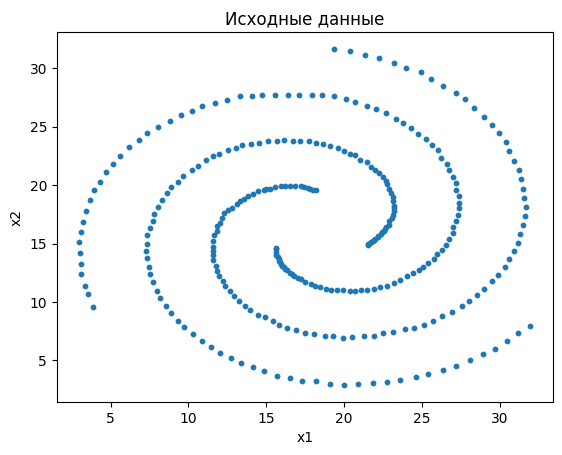

In [ ]:
plt.scatter(X[:, 0], X[:, 1], s=10)
plt.title("Исходные данные")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

Датасет представляет собой двумерные точки (x1, x2), визуально образующие три спирали.

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X)

centers = kmeans.cluster_centers_

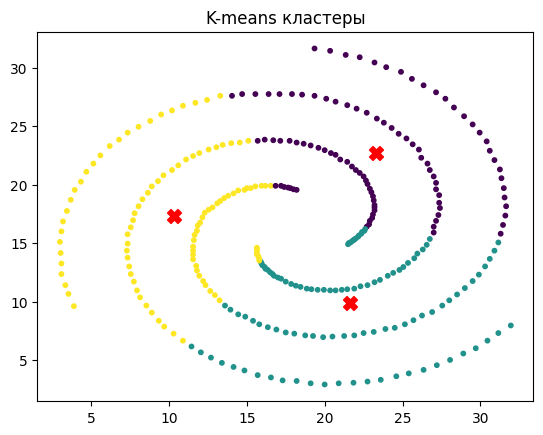

In [ ]:
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=10)
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=100, marker='X')
plt.title("K-means кластеры")
plt.show()

Был применён алгоритм K-means с числом кластеров = 3. Алгоритм:

a) случайно инициализирует центры кластеров;

б) распределяет точки по ближайшим центрам;

в) пересчитывает центры;

г) повторяет до сходимости.

Цветами обозначены найденные кластеры. Красные кресты являются центроидами классов.

Видно из графика:

1. Алгоритм не восстановил спиральную структуру.

2. Кластеры разделены радиально, а не по спиралям.

3. Точки одной спирали попадают в разные кластеры.

Silhouette score: 0.36036526477196046


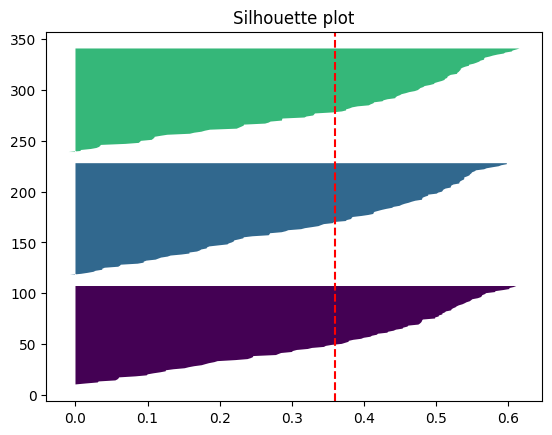

In [ ]:
from sklearn.metrics import silhouette_score, silhouette_samples

score = silhouette_score(X, labels)
print("Silhouette score:", score)

import matplotlib.cm as cm

sample_silhouette_values = silhouette_samples(X, labels)

y_lower = 10
for i in range(3):
    ith_cluster_silhouette_values = sample_silhouette_values[labels == i]
    ith_cluster_silhouette_values.sort()

    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i

    color = cm.viridis(float(i) / 3)
    plt.fill_betweenx(np.arange(y_lower, y_upper),
                      0, ith_cluster_silhouette_values,
                      facecolor=color)

    y_lower = y_upper + 10

plt.axvline(x=score, color="red", linestyle="--")
plt.title("Silhouette plot")
plt.show()

Точки в среднем находятся чуть ближе к своему кластеру, чем к чужим, но разделение не сильное. У всех трёх кластеров большинство значений silhouette положительные, то есть алгоритм всё же выделил осмысленные группы. При этом много точек лежит в зоне примерно 0,0–0,3, а это признак слабого разделения и заметного перекрытия кластеров. K-means частично справился с задачей, не идеально. Индекс силуэта примерно равен 0,360. Это говорит о среднем качестве кластеризации, но приближенном к слабому.

Cправился ли
алгоритм с датасетом? Какие ограничения
k-means помешали этому?

Ответ:

Алгоритм k-means показал неудовлетворительное качество кластеризации на данном датасете. Несмотря на задание оптимального числа кластеров (k=3), алгоритм не смог корректно восстановить структуру данных, поскольку кластеры имеют сложную нелинейную форму спирали (точки одного истинного класса попали в разные кластеры). K-means предполагает выпуклые и компактные кластеры и использует евклидово расстояние (точки одной спирали могут быть далеко по прямой, но логически принадлежат одному кластеру), что делает его неэффективным для подобных задач. Это подтверждается визуализацией и низким значением silhouette score (0,360).